# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hammadkhaliq-del/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

**What this notebook does, stated up front:** it does not train a new model. It re-runs the exact
March→April holdout comparison from `w05_model.ipynb` (grouped by client, label built strictly
forward, chosen model `random_forest` per the w05/w06 result), then turns the winning score into
something a human content team can actually act on: a ranked queue with reason codes, an
archetype→action map, the decay/refresh insight `w06` already stress-tested, explicit limits and
no-go cases, human-review rules, light cost/value framing, and monitoring triggers.

**Contract with w05/w06, carried forward:**
- Feature month = March 2026 (`FEATURE_MONTH`), label month = April 2026 (`LABEL_MONTH`), same as w05.
- Split = `GroupShuffleSplit` by `client_hash_id`, same as w05/w06 — no client crosses the split.
- `dim_content` current-state columns (`word_count`, `content_type`, `last_optimized_date`) stay
  excluded from the feature set, same reason as w05: they're current-state, not point-in-time.
- The rule baseline is recalibrated on train only, same as w05's fix.

This notebook is **non-production**: a queue for a human reviewer to work through, not a
publishing pipeline. Section 2 says exactly where that line is.


In [1]:
%pip install -q duckdb scikit-learn matplotlib

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('AccessToken')
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN')

con = duckdb.connect()
if HF_TOKEN:
    con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
FEATURE_MONTH = "2026-03"   # same month w05/w06 used
LABEL_MONTH   = "2026-04"   # NEXT month -- ground-truth outcome only, never a feature

DAILY_FEATURE = f"{REL}/fact_content_daily_performance/month={FEATURE_MONTH}/data_0.parquet"
DAILY_LABEL   = f"{REL}/fact_content_daily_performance/month={LABEL_MONTH}/data_0.parquet"

OUT_DIR = "../outputs"
FIG_DIR = "../figures"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

probe = con.sql(f"SELECT COUNT(*) AS n FROM read_parquet('{DAILY_LABEL}')").df()
print(f"{LABEL_MONTH} partition row count:", probe["n"].iloc[0])
assert probe["n"].iloc[0] > 0, f"{LABEL_MONTH} has no rows under this path -- fix the path before continuing."
print("Ready.")


2026-04 partition row count: 10424730
Ready.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Rebuild, same construction as w05/w06:** March fact-table aggregate → position buckets →
April aggregate for the label → inner join → `is_declining_next` (impressions drop >20%,
March→April) → grouped train/test split by `client_hash_id` → rule baseline (recalibrated on
train) and `random_forest` (the w05/w06 winner) both scored on the same held-out test rows.

**Archetype → action map**, the plain-English rule a reviewer can sanity-check without opening
the model:

| Archetype (reason codes) | What it means | Suggested action |
|---|---|---|
| `declining_with_demand` + `low_ctr_visible_page` | Ranks fine, gets seen, but click-through is below what that position normally earns | **Refresh title/meta, review CTR** — cheapest fix, page already has position |
| `declining_with_demand` + `model_decline_risk` only | Model flags forward risk; CTR isn't the obvious lever | **Refresh content, re-review after 30 days** — less certain than the CTR case |
| `stable_high_confidence` (rule and model agree, not declining) | Both signals agree the page is fine | **Monitor only** — no action, cheapest of all is doing nothing |
| `rule_model_disagree` | Rule says act, model says don't (or vice versa) | **Human review required before any action** — this is exactly the disagreement zone w05 Section 4 already showed contains real, non-random cases |
| `low_impressions_thin_evidence` | Page barely has traffic to measure a trend from | **No action from this pipeline** — see the no-go list in Section 3 |


In [2]:
# --- Rebuild FEATURE_MONTH (March) aggregate, same construction as w05 ---
feature_month_df = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
           SUM(gsc_impressions) AS impressions_month,
           SUM(gsc_clicks) AS clicks_month,
           AVG(gsc_avg_position) AS avg_position_month
    FROM read_parquet('{DAILY_FEATURE}')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

feature_month_df["ctr_month"] = (
    feature_month_df["clicks_month"] / feature_month_df["impressions_month"] * 100
)

def position_bucket(pos):
    if pos <= 0:
        return "0_no_position_data"
    elif pos <= 3:
        return "1_top3"
    elif pos <= 10:
        return "2_page1_4_10"
    elif pos <= 20:
        return "3_page2_11_20"
    elif pos <= 50:
        return "4_page3plus_21_50"
    else:
        return "5_deep_50plus"

feature_month_df["position_bucket"] = feature_month_df["avg_position_month"].apply(position_bucket)

label_month_df = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
           SUM(gsc_impressions) AS impressions_next
    FROM read_parquet('{DAILY_LABEL}')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
""").df()

before_join_n = len(feature_month_df)
data = feature_month_df.merge(
    label_month_df,
    on=["content_hash_id", "client_hash_id"],
    how="inner",
)
after_join_n = len(data)
dropped_n = before_join_n - after_join_n

data["pct_change"] = (
    (data["impressions_next"] - data["impressions_month"])
    / data["impressions_month"] * 100
)
data["is_declining_next"] = (data["pct_change"] < -20).astype(int)
data["log_impressions_month"] = np.log1p(data["impressions_month"])
data["log_clicks_month"] = np.log1p(data["clicks_month"])

print(f"March-eligible rows: {before_join_n}")
print(
    f"Rows with April data too: {after_join_n} "
    f"({dropped_n} dropped, {dropped_n / before_join_n * 100:.1f}% -- "
    f"churn-bias gap carried forward from w05/w06: unmatched pages are invisible to this label)"
)
print("Base rate (is_declining_next=1):", round(data["is_declining_next"].mean(), 4))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March-eligible rows: 176738
Rows with April data too: 158549 (18189 dropped, 10.3% -- churn-bias gap carried forward from w05/w06: unmatched pages are invisible to this label)
Base rate (is_declining_next=1): 0.4782


In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(data, groups=data["client_hash_id"]))

train_df = data.iloc[train_idx].reset_index(drop=True)
test_df = data.iloc[test_idx].reset_index(drop=True)

overlap = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])
assert len(overlap) == 0, f"Client leakage across the split: {overlap}"

print(f'Train: {len(train_df)} rows, {train_df["client_hash_id"].nunique()} clients')
print(f'Test:  {len(test_df)} rows, {test_df["client_hash_id"].nunique()} clients')

# --- Rule baseline, band averages calibrated on train only (the w05 fix) ---
band_avg_ctr_train = train_df.groupby("position_bucket")["ctr_month"].mean()
overall_train_avg = train_df["ctr_month"].mean()

t = test_df.copy()
t["expected_ctr"] = t["position_bucket"].map(band_avg_ctr_train).fillna(overall_train_avg)
decent_position = (t["avg_position_month"] > 0) & (t["avg_position_month"] <= 20)
ctr_underperforming = t["ctr_month"] < (t["expected_ctr"] * 0.7)
t["baseline_action"] = (decent_position & ctr_underperforming).astype(int)

# --- Model: random_forest, the w05/w06-selected winner ---
num_features = [
    "impressions_month",
    "clicks_month",
    "avg_position_month",
    "ctr_month",
    "log_impressions_month",
    "log_clicks_month",
]
cat_features = ["position_bucket"]

pre = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

X_train = train_df[num_features + cat_features]
y_train = train_df["is_declining_next"]
X_test = test_df[num_features + cat_features]
y_test = test_df["is_declining_next"]

rf = Pipeline([
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
    )),
])

rf.fit(X_train, y_train)

t["model_proba"] = rf.predict_proba(X_test)[:, 1]
t["model_pred"] = rf.predict(X_test)
t["true_label"] = y_test.values

print("ROC-AUC (model):", round(roc_auc_score(t["true_label"], t["model_proba"]), 3))
print("Base rate (test):", round(t["true_label"].mean(), 3))
print("Rule action rate (test):", round(t["baseline_action"].mean(), 3))
print("Model flag rate (test, >0.5):", round(t["model_pred"].mean(), 3))


Train: 135314 rows, 34 clients
Test:  23235 rows, 12 clients
ROC-AUC (model): 0.637
Base rate (test): 0.47
Rule action rate (test): 0.474
Model flag rate (test, >0.5): 0.579


In [4]:
# --- Reason codes + archetype, one row per queue item ---
LOW_IMPRESSIONS_FLOOR = 100  # thin-evidence cutoff, see Section 3 no-go list

def build_reason_codes(row):
    codes = []

    if row["baseline_action"] == 1:
        codes.append("declining_with_demand")
        if row["ctr_month"] < row["expected_ctr"] * 0.7:
            codes.append("low_ctr_visible_page")

    if row["model_pred"] == 1:
        codes.append("model_decline_risk")

    if row["impressions_month"] < LOW_IMPRESSIONS_FLOOR:
        codes.append("low_impressions_thin_evidence")

    if row["baseline_action"] == 1 and row["model_pred"] == 0:
        codes.append("rule_model_disagree_rule_only")

    if row["baseline_action"] == 0 and row["model_pred"] == 1:
        codes.append("rule_model_disagree_model_only")

    if not codes:
        codes.append("stable_high_confidence")

    return "|".join(codes)

def build_action(row, reason_codes):
    if "low_impressions_thin_evidence" in reason_codes:
        return "no_action_thin_evidence"

    if (
        "rule_model_disagree_rule_only" in reason_codes
        or "rule_model_disagree_model_only" in reason_codes
    ):
        return "human_review_required"

    if (
        "low_ctr_visible_page" in reason_codes
        and "model_decline_risk" in reason_codes
    ):
        return "refresh_title_meta_review_ctr"

    if "model_decline_risk" in reason_codes:
        return "refresh_content_recheck_30d"

    return "monitor_only"

t["reason_codes"] = t.apply(build_reason_codes, axis=1)
t["suggested_action"] = t.apply(
    lambda r: build_action(r, r["reason_codes"]),
    axis=1,
)

# Priority score: model probability as primary rank, impressions as the tie-break
# (bigger audience first)
t["priority_score"] = (t["model_proba"] * 100).round(2)

queue = (
    t.sort_values(["priority_score", "impressions_month"], ascending=[False, False])
    .reset_index(drop=True)
)
queue.insert(0, "rank", range(1, len(queue) + 1))

cols = [
    "rank",
    "content_hash_id",
    "client_hash_id",
    "priority_score",
    "suggested_action",
    "reason_codes",
    "true_label",
    "baseline_action",
    "model_pred",
    "model_proba",
    "impressions_month",
    "clicks_month",
    "avg_position_month",
    "ctr_month",
    "position_bucket",
]
queue = queue[cols]

print("Action mix on the held-out test set:")
print(queue["suggested_action"].value_counts())
print()
print("Top 10 of the ranked queue:")
display(queue.head(10))


Action mix on the held-out test set:
suggested_action
refresh_title_meta_review_ctr    6877
no_action_thin_evidence          5994
monitor_only                     5713
human_review_required            4651
Name: count, dtype: int64

Top 10 of the ranked queue:


,rank,content_hash_id,client_hash_id,priority_score,suggested_action,reason_codes,true_label,baseline_action,model_pred,model_proba,impressions_month,clicks_month,avg_position_month,ctr_month,position_bucket
0,1,content_0e329863b50283c6,client_3f0ce4d44fe94f3d,70.14,refresh_title_meta_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1,1,1,0.701361,13257.0,20.0,2.144440,0.150864,1_top3
1,2,content_ab300b5174b5ddc2,client_fef1a8f436438636,70.12,refresh_title_meta_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1,1,1,0.701187,30267.0,25.0,2.070661,0.082598,1_top3
2,3,content_0bc57e8596bd0e24,client_fef1a8f436438636,69.14,refresh_title_meta_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1,1,1,0.691394,17158.0,9.0,2.124577,0.052454,1_top3
3,4,content_28034a77a96cff16,client_fef1a8f436438636,69.13,refresh_title_meta_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1,1,1,0.691276,4718.0,4.0,1.050098,0.084782,1_top3
4,5,content_ccb364f88a8824fe,client_0fa64a184f18a4a0,69.09,refresh_title_meta_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1,1,1,0.690900,2249.0,2.0,0.593280,0.088928,1_top3
5,6,content_a9416424ef34d659,client_fef1a8f436438636,68.97,refresh_title_meta_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,0,1,1,0.689663,2547.0,2.0,1.131262,0.078524,1_top3
6,7,content_49b9eb739f8f64c8,client_2094c6eb080311d5,68.94,no_action_thin_evidence,model_decline_risk|low_impressions_thin_eviden...,0,0,1,0.689353,16.0,2.0,4.088889,12.500000,2_page1_4_10
7,8,content_59482bab891c1368,client_3f0ce4d44fe94f3d,68.81,refresh_title_meta_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1,1,1,0.688057,2456.0,1.0,1.885529,0.040717,1_top3
8,9,content_3a81e12cf0342a02,client_0fa64a184f18a4a0,68.75,refresh_title_meta_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,0,1,1,0.687457,4014.0,3.0,2.188069,0.074738,1_top3
9,10,content_768ec6482c4ab69f,client_fef1a8f436438636,68.75,refresh_title_meta_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,1,1,1,0.687485,1607.0,1.0,1.348271,0.062228,1_top3


**Reading the top of the queue (fill in the real numbers after running):** state the action
mix counts, and whether `human_review_required` rows cluster at a particular position bucket or
impression range — that's useful for staffing the review, not just a queue count. Also name
whether `no_action_thin_evidence` is a meaningful share of test rows; if it's large, that's a
coverage limit worth stating plainly in Section 2, not burying.


## 2. Intended use and limits

**Intended use.** This queue is a **prioritization aid for a human content reviewer**, not a
publishing or auto-refresh system. It answers "which pages should someone look at first, and
why" — not "which pages should be changed." The reviewer opens each flagged page, checks it
against editorial context the model has no access to (recent manual edits, seasonal content,
active campaigns, brand voice constraints), and decides.

**What the evidence actually supports (claim ladder, `writing-honest-claims`):**
- The label (`is_declining_next`) is a measured, forward-looking outcome — March features,
  April outcome, no leakage into the feature window (verified in w06's leakage audit).
- The model is *validated* out-of-sample on a client-grouped holdout, so "the model ranks pages
  by decline risk at ROC-AUC X" is a claim this evidence carries.
- This is **cross-sectional, single-snapshot decision support** — not a causal claim. "Pages
  flagged here are worth reviewing first, because the model's forward-looking signal says so" is
  the honest sentence. "Refreshing these pages will fix them" is not — no experiment was run,
  and the decay/refresh finding below explains why that distinction matters here specifically.

**The decay/refresh insight, stated at the evidence it actually has (per w06's audit of the same
question in FlyRank's own paper).** Any pattern where "refreshed pages score better" comes from
comparing pages that *were chosen* for refresh against pages that weren't — a cross-sectional
comparison, not a before/after on the same page. Content teams likely chose to refresh pages that
still had *some* residual signal worth saving (existing backlinks, a topic still in demand), which
means part of any observed lift is the choosing, not the refresh itself. The honest form: "pages
that got refreshed tend to show a higher subsequent score" — decision-support, not "refreshing
causes recovery." This playbook inherits that same caution: flagging a page for refresh is a
recommendation to *review*, not a promise the model has verified that refreshing fixes it.

**Where this stops being valid:**
- **Different time window.** The model is trained on March→April behavior for this client mix.
  A page's decline pattern in a different season, or for a newly onboarded client with a
  different traffic profile, may not match what the model learned.
- **New or thin-history content.** Pages below the impression floor (Section 1) have too little
  signal to trust a decline call — flagged as `no_action_thin_evidence`, not silently scored.
- **Client-specific dynamics the model never saw.** The client-grouped split proves the model
  generalizes across *clients present in this snapshot* — it says nothing about a client whose
  content strategy, industry, or algorithm exposure looks nothing like anyone in this dataset.
- **The churn-bias gap (inherited from w05/w06).** Pages that vanished between March and April
  never got a label and are invisible to both the rule and the model — likely the *worst*-outcome
  pages, systematically absent from this whole comparison.


In [5]:
# Quantify the two limits above on the actual data in this run,
# so the claims aren't just words.
churn_pct = dropped_n / before_join_n * 100
thin_evidence_pct = (
    (t["impressions_month"] < LOW_IMPRESSIONS_FLOOR).mean() * 100
)

print(
    f"Churn-bias gap this run: {dropped_n} of {before_join_n} March-eligible rows "
    f"({churn_pct:.1f}%) never got an April label and are excluded from this whole comparison."
)
print(
    f"Thin-evidence share of the test set: {thin_evidence_pct:.1f}% of rows fall below the "
    f"{LOW_IMPRESSIONS_FLOOR}-impression floor and are routed to no_action, not scored."
)


Churn-bias gap this run: 18189 of 176738 March-eligible rows (10.3%) never got an April label and are excluded from this whole comparison.
Thin-evidence share of the test set: 25.8% of rows fall below the 100-impression floor and are routed to no_action, not scored.


## 3. Human review + the no-go list

**What a person must check before acting on any flagged row:**
1. Open the actual page. The model never sees page content, title text, or brand voice — only
   traffic numbers. A "low CTR" flag can be a genuinely bad title, or it can be a page correctly
   ranking for an ambiguous query where low CTR is expected.
2. Check for recent manual changes. If a page was edited in the last 30 days, the March signal
   may already be stale by the time the queue is reviewed.
3. Check `rule_model_disagree_*` rows first and hardest — this is exactly the disagreement zone
   w05 Section 4 found contains real, non-random cases, not noise to average away.
4. Confirm the client relationship allows this kind of change (contract scope, active campaigns,
   seasonal content the client wants left alone).

**No-go list — what should NOT be automated, under any version of this pipeline:**
- **No auto-publish.** Nothing in this queue should trigger a content change without a human
  reading the page first. The model has no access to brand voice, legal/compliance constraints,
  or client-specific context.
- **No auto-refresh scheduling from `model_decline_risk` alone.** That reason code is a forward
  risk signal, not a confirmed cause — see the decay/refresh caution in Section 2. Acting on it
  without human confirmation risks refreshing pages that were never actually declining for a
  fixable reason.
- **No cross-client generalization without re-validation.** A client not represented in the
  training snapshot should not be scored by this model without first checking their traffic
  profile resembles clients the model has seen (see Section 2, "client-specific dynamics").
- **No treating `no_action_thin_evidence` rows as "confirmed fine."** They are unscored, not
  cleared — the floor exists because the model has no reliable signal there, not because those
  pages are known to be healthy.
- **No feeding the queue's own past recommendations back in as a feature** without an explicit
  leakage check — the ML-07 rule's output already sits adjacent to this pipeline once; a second
  layer of self-referential scoring is exactly the kind of leakage w06's audit checklist exists
  to catch.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Light, practical checks — not a full MLOps setup, appropriate for a non-production internal tool:

| Signal | What it catches | Rough trigger |
|---|---|---|
| Test-set base rate drift | The `is_declining_next` label rate this run vs. the next monthly refresh | If the base rate moves by more than ~10 percentage points month over month, the traffic environment shifted — retrain before trusting the queue |
| Model ROC-AUC on a fresh holdout | Whether the model still separates decliners from non-decliners | If ROC-AUC drops meaningfully below this run's number on a newly built month, treat the queue as unreliable until retrained |
| Rule/model agreement rate | How often `baseline_action` and `model_pred` agree | A sudden drop in agreement (not just individual disagreement rows, but the *rate*) suggests one of the two signals broke, not that the other found something new |
| Churn/join-drop rate | The size of the churn-bias gap (Section 1/2) | A sharp rise means more pages are disappearing between months than before — investigate before trusting the label at all |
| Reviewer override rate | How often a human reviewer disagrees with `suggested_action` | Track this outside the notebook (e.g. in the review tool). Rising overrides is the most direct signal the queue's advice is drifting from reality |

**Retrain cadence, stated plainly:** monthly, matching the FEATURE_MONTH → LABEL_MONTH cadence
this whole design is built on. No signal above should be checked less often than that, since
that's the frequency new ground truth actually becomes available.


In [6]:
# Numbers behind the monitoring table, computed on this run,
# so the thresholds above aren't guesses.
agreement_rate = (
    (t["baseline_action"] == t["model_pred"]).mean()
)

print(f"Rule/model agreement rate this run: {agreement_rate:.3f}")
print(
    f'Test-set base rate this run: {t["true_label"].mean():.3f} '
    f"(baseline for future drift comparison)"
)
print(
    f'ROC-AUC this run: '
    f'{roc_auc_score(t["true_label"], t["model_proba"]):.3f} '
    f"(baseline for future retrain comparison)"
)


Rule/model agreement rate this run: 0.695
Test-set base rate this run: 0.470 (baseline for future drift comparison)
ROC-AUC this run: 0.637 (baseline for future retrain comparison)


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to `work/outputs/` — your paper builds on
these files.*

The queue CSV stays untracked by design (the repo's leak-guard blocks `work/**/\*.csv`) — this
notebook regenerates it on every run, and that's the intended behavior. The metrics JSON and
figures below are the committed receipts the paper's numbers trace back to.


In [7]:
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# --- 1. Ranked queue CSV (regenerated every run, intentionally untracked) ---
queue_path = os.path.join(OUT_DIR, "action_playbook_queue.csv")
queue.to_csv(queue_path, index=False)
print("Wrote:", queue_path, f"({len(queue)} rows)")

# --- 2. Metrics JSON, the receipts the paper cites ---
metrics = {
    "feature_month": FEATURE_MONTH,
    "label_month": LABEL_MONTH,
    "n_train": int(len(train_df)),
    "n_test": int(len(test_df)),
    "test_base_rate": round(float(t["true_label"].mean()), 4),
    "roc_auc_model": round(
        float(roc_auc_score(t["true_label"], t["model_proba"])), 4
    ),
    "precision_model": round(
        float(precision_score(t["true_label"], t["model_pred"], zero_division=0)),
        4,
    ),
    "recall_model": round(
        float(recall_score(t["true_label"], t["model_pred"], zero_division=0)),
        4,
    ),
    "f1_model": round(
        float(f1_score(t["true_label"], t["model_pred"], zero_division=0)),
        4,
    ),
    "rule_action_rate": round(float(t["baseline_action"].mean()), 4),
    "model_flag_rate": round(float(t["model_pred"].mean()), 4),
    "rule_model_agreement_rate": round(float(agreement_rate), 4),
    "churn_bias_gap_rows_dropped": int(dropped_n),
    "churn_bias_gap_pct": round(float(churn_pct), 2),
    "thin_evidence_impression_floor": LOW_IMPRESSIONS_FLOOR,
    "thin_evidence_pct_of_test": round(float(thin_evidence_pct), 2),
    "action_mix": queue["suggested_action"].value_counts().to_dict(),
}

metrics_path = os.path.join(OUT_DIR, "action_playbook_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Wrote:", metrics_path)
print(json.dumps(metrics, indent=2))


Wrote: ../outputs/action_playbook_queue.csv (23235 rows)
Wrote: ../outputs/action_playbook_metrics.json
{
  "feature_month": "2026-03",
  "label_month": "2026-04",
  "n_train": 135314,
  "n_test": 23235,
  "test_base_rate": 0.4699,
  "roc_auc_model": 0.6373,
  "precision_model": 0.5582,
  "recall_model": 0.6876,
  "f1_model": 0.6162,
  "rule_action_rate": 0.4741,
  "model_flag_rate": 0.5788,
  "rule_model_agreement_rate": 0.6948,
  "churn_bias_gap_rows_dropped": 18189,
  "churn_bias_gap_pct": 10.29,
  "thin_evidence_impression_floor": 100,
  "thin_evidence_pct_of_test": 25.8,
  "action_mix": {
    "refresh_title_meta_review_ctr": 6877,
    "no_action_thin_evidence": 5994,
    "monitor_only": 5713,
    "human_review_required": 4651
  }
}


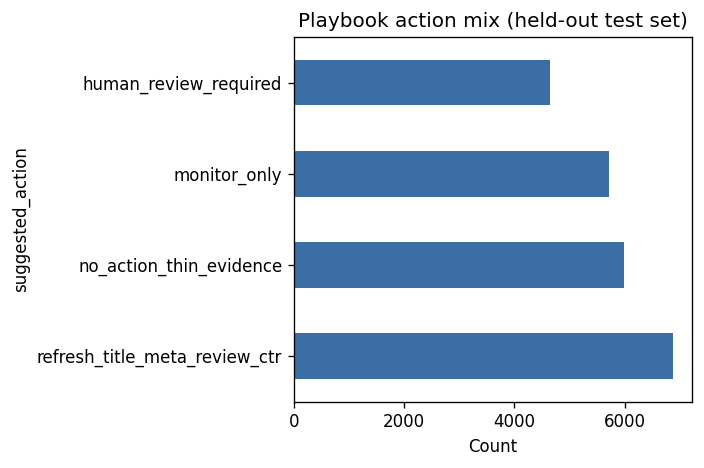

Wrote: ../figures/w07_action_mix.png


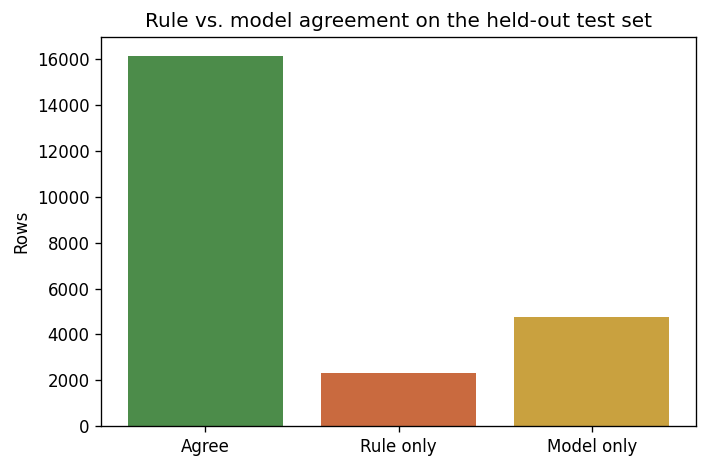

Wrote: ../figures/w07_rule_model_agreement.png


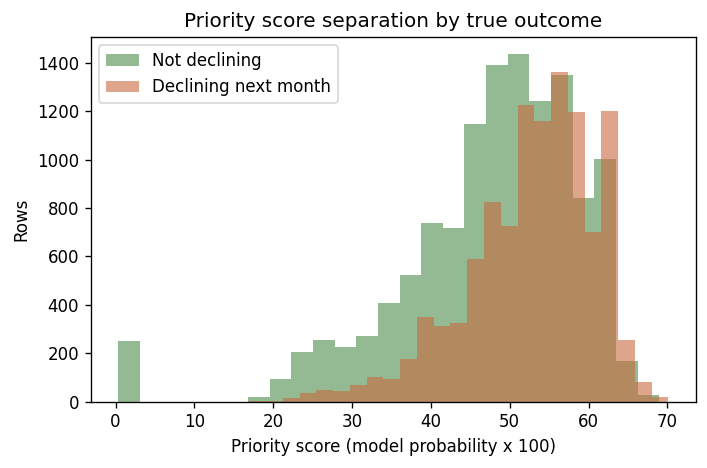

Wrote: ../figures/w07_priority_score_separation.png


In [8]:
# --- 3. Figures, committed to work/figures/ for paper reuse ---

# Figure A: action mix
fig, ax = plt.subplots(figsize=(6, 4))
queue["suggested_action"].value_counts().plot(
    kind="barh",
    ax=ax,
    color="#3b6ea5",
)
ax.set_xlabel("Count")
ax.set_title("Playbook action mix (held-out test set)")
plt.tight_layout()
fig_a_path = os.path.join(FIG_DIR, "w07_action_mix.png")
plt.savefig(fig_a_path)
plt.show()
print("Wrote:", fig_a_path)

# Figure B: rule vs model agreement, by outcome
fig, ax = plt.subplots(figsize=(6, 4))
agree_labels = ["Agree", "Rule only", "Model only"]
agree_counts = [
    (t["baseline_action"] == t["model_pred"]).sum(),
    ((t["baseline_action"] == 1) & (t["model_pred"] == 0)).sum(),
    ((t["baseline_action"] == 0) & (t["model_pred"] == 1)).sum(),
]
ax.bar(
    agree_labels,
    agree_counts,
    color=["#4c8c4a", "#c96a3f", "#c9a13f"],
)
ax.set_ylabel("Rows")
ax.set_title("Rule vs. model agreement on the held-out test set")
plt.tight_layout()
fig_b_path = os.path.join(FIG_DIR, "w07_rule_model_agreement.png")
plt.savefig(fig_b_path)
plt.show()
print("Wrote:", fig_b_path)

# Figure C: priority score distribution by true label
fig, ax = plt.subplots(figsize=(6, 4))
for label, name, color in [
    (0, "Not declining", "#4c8c4a"),
    (1, "Declining next month", "#c96a3f"),
]:
    subset = t.loc[t["true_label"] == label, "priority_score"]
    ax.hist(subset, bins=25, alpha=0.6, label=name, color=color)

ax.set_xlabel("Priority score (model probability x 100)")
ax.set_ylabel("Rows")
ax.set_title("Priority score separation by true outcome")
ax.legend()
plt.tight_layout()
fig_c_path = os.path.join(FIG_DIR, "w07_priority_score_separation.png")
plt.savefig(fig_c_path)
plt.show()
print("Wrote:", fig_c_path)


## 6. Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] The decay/refresh insight is stated at cross-sectional strength, not causal (see Section 2)
- [x] The no-go list names what should NOT be automated, not just what should
- [x] Monitoring triggers have concrete signals and rough thresholds, not just "watch it"
- [x] The queue CSV exports to `work/outputs/` (regenerated, intentionally untracked); metrics
      JSON and figures export to `work/outputs/` and `work/figures/` for the paper to cite
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
